In [1]:
%pip install ipympl
%matplotlib widget

Note: you may need to restart the kernel to use updated packages.


In [2]:
from enum import auto
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import stft
from scipy.fft import fft, fftfreq, fftshift, ifft
import math

In [3]:
def transform(file_name):
    sample_rate, data = wavfile.read(file_name)
    left_data = data[:, 0]
    right_data = data[:, 1]
    
    f_transform_left = fft(left_data)
    f_left = fftfreq(len(left_data), 1/sample_rate)
    amplitude_left = np.abs(f_transform_left) / (len(left_data) / 2)

    f_transform_right = fft(right_data)
    f_right = fftfreq(len(right_data), 1/sample_rate)
    amplitude_right = np.abs(f_transform_right) / (len(right_data) / 2)

    return left_data, f_transform_left, f_left, amplitude_left, right_data, f_transform_right, f_right, amplitude_right, sample_rate

In [4]:
def plot(x, y, title, xlabel, ylabel):
    plt.figure(figsize=(10, 4))
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.plot(x, y)
    plt.tight_layout()
    plt.show()


C:\Users\eranm\AppData\Local\Temp\ipykernel_38716\730090391.py:2: WavFileWarning: Reached EOF prematurely; finished at 39342193 bytes, expected 4294967303 bytes from header.
  sample_rate, data = wavfile.read(file_name)


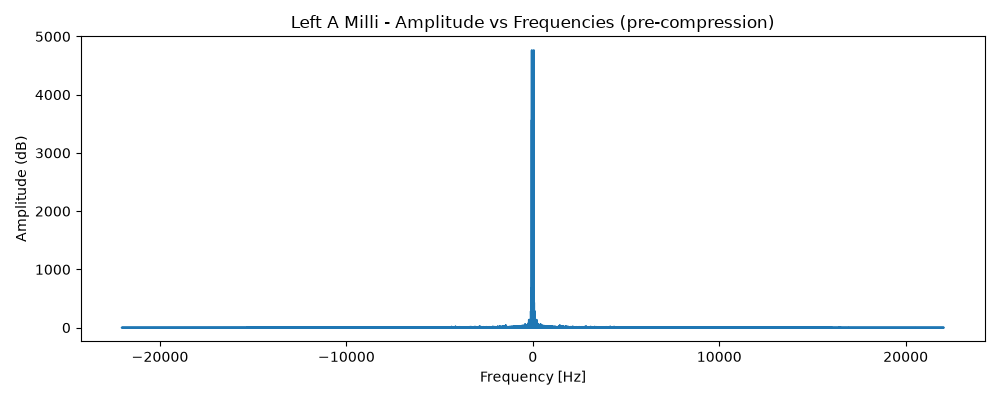

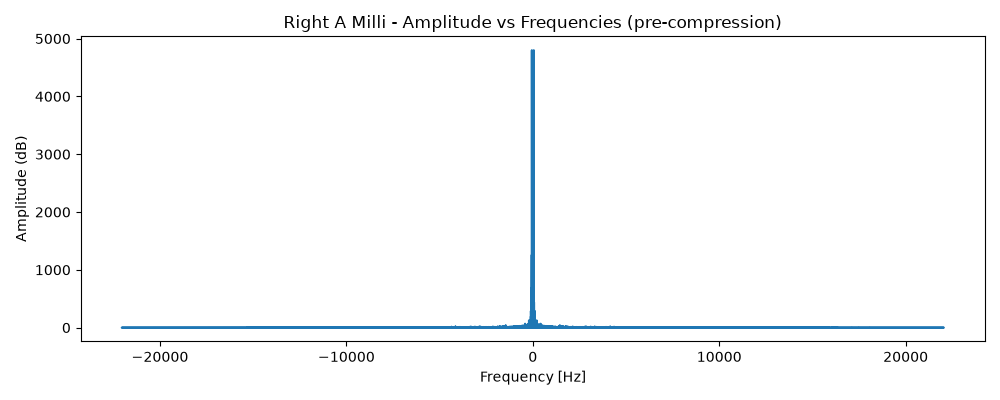

In [5]:
right_limit = 23000

left_data, f_transform_left, f_left, amplitude_left, right_data, f_transform_right, f_right, amplitude_right, sample_rate = transform('a_milli.wav')
plot(f_left, amplitude_left,  'Left A Milli - Amplitude vs Frequencies (pre-compression)', 'Frequency [Hz]', 'Amplitude (dB)')
plot(f_right,  amplitude_right,  'Right A Milli - Amplitude vs Frequencies (pre-compression)', 'Frequency [Hz]', 'Amplitude (dB)')

In [6]:
def remove_dc_offset(f_transform, data):
    f_transform[0] = 0
    amplitude = np.abs(f_transform) / (len(data) / 2)
    return amplitude, f_transform

In [ ]:
def adjust_to_speaker_freqs(sample_rate, f_transform):
    #35Hz to #20kHz
    #find indices by sampling frequency/#samples * frequency
    n = f_transform.size
    delta_f = n/sample_rate
    min_freq_index = int(35*delta_f)
    max_freq_index = int(20000*delta_f)
    f_transform[:min_freq_index+1] = 0
    f_transform[-min_freq_index:] = 0
    
    f_transform[max_freq_index:-max_freq_index] = 0
    
    amplitude = np.abs(f_transform) / (n / 2)
    return amplitude, f_transform

In [ ]:
def adjust_to_iphone_freqs(sample_rate, f_transform):
    #35Hz to #20kHz
    #find indices by sampling frequency/#samples * frequency
    n = f_transform.size
    delta_f = n/sample_rate
    min_freq_index = int(200*delta_f)
    max_freq_index = int(16000*delta_f)
    f_transform[:min_freq_index+1] = 0
    f_transform[-min_freq_index:] = 0
    f_transform[max_freq_index:-max_freq_index] = 0
    
    amplitude = np.abs(f_transform) / (n / 2)
    return amplitude, f_transform

In [ ]:
def missing_fundamental(sample_rate, f_transform):
    length = f_transform.size
    delta_f = length/sample_rate
    min_audible_index = int(20*delta_f)+1
    min_freq_index = int(200*delta_f)+1
    for i in range(min_audible_index, min_freq_index):
        #minimum harmonic that is >= min_freq_index
        n = math.ceil(200/(i*delta_f))
        n_index = n*i
        n_p1_index = (n+1)*n
        n_p2_index = (n+2)*n

        contrib_0 = f_transform[i] / n
        contrib_1 = f_transform[i] / (n+1)
        contrib_2 = f_transform[i] / (n+2)
        
        f_transform[n_index] += contrib_0
        f_transform[-n_index] += np.conj(contrib_0)
        f_transform[n_p1_index] += contrib_1
        f_transform[-n_p1_index] += np.conj(contrib_1)
        f_transform[n_p2_index] += contrib_2
        f_transform[-n_p2_index] += np.conj(contrib_2)

    # print(-min_freq_index)
    # print(-twenty_index)
    # for i in range(-min_freq_index, -twenty_index):
    #     print("I: ", i)
    #     n = math.ceil(200/f[i])
    #     nth_harmonic = n*f[i]
    #     n_p1_harmonic = (n+1)*f[i]
    #     n_p2_harmonic = (n+2)*f[i]
    #     n_index = int(nth_harmonic*length/sample_rate)
    #     n_p1_index = int(n_p1_harmonic*length/sample_rate)
    #     n_p2_index = int(n_p2_harmonic*length/sample_rate)
    #     print("N: ", n)
    #     print("nth_harmony: ", nth_harmonic)
    #     print("index: ", n_index)
    #     f_transform[n_index] = f_transform[n_index] + (f_transform[i] / n)
    #     f_transform[n_p1_index] = f_transform[n_p1_index] + (f_transform[i] / (n+1))
    #     f_transform[n_p2_index] = f_transform[n_p2_index] + (f_transform[i] / (n+1))

    amplitude = np.abs(f_transform) / (length / 2)
    return amplitude, f_transform


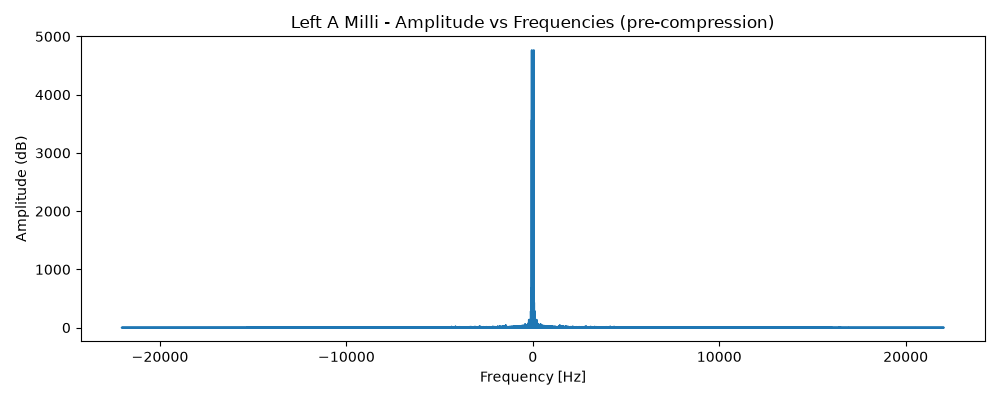

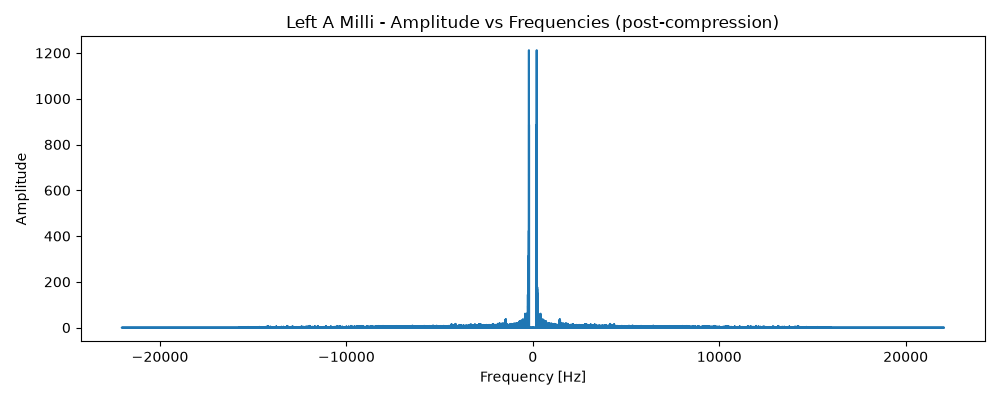

In [ ]:
al, ftl = missing_fundamental(sample_rate, f_left, f_transform_left.copy())
ar, ftr = missing_fundamental(sample_rate, f_right, f_transform_right.copy())
amplitude_left_new, f_transform_left_new = adjust_to_iphone_freqs(sample_rate, ftl)
amplitude_right_new, f_transform_right_new = adjust_to_iphone_freqs(sample_rate, ftr)

plot(f_left, amplitude_left,  'Left A Milli - Amplitude vs Frequencies (pre-compression)', 'Frequency [Hz]', 'Amplitude (dB)')
plot(f_left, amplitude_left_new,  'Left A Milli - Amplitude vs Frequencies (post-compression)', 'Frequency [Hz]', 'Amplitude')

In [11]:
def inverse_transform(left, right, sample_rate, output_filename):
    reconstructed_left = ifft(left)
    reconstructed_right = ifft(right)

    reconstructed_left_real = np.real(reconstructed_left)
    reconstructed_right_real = np.real(reconstructed_right)
  
    reconstructed_real = np.stack((reconstructed_left_real, reconstructed_right_real), axis=1)
    audio_data_int16 = np.int16(np.clip(reconstructed_real, -32768, 32767))
    
    wavfile.write(output_filename, sample_rate, audio_data_int16)

    return audio_data_int16

6691.835504020123


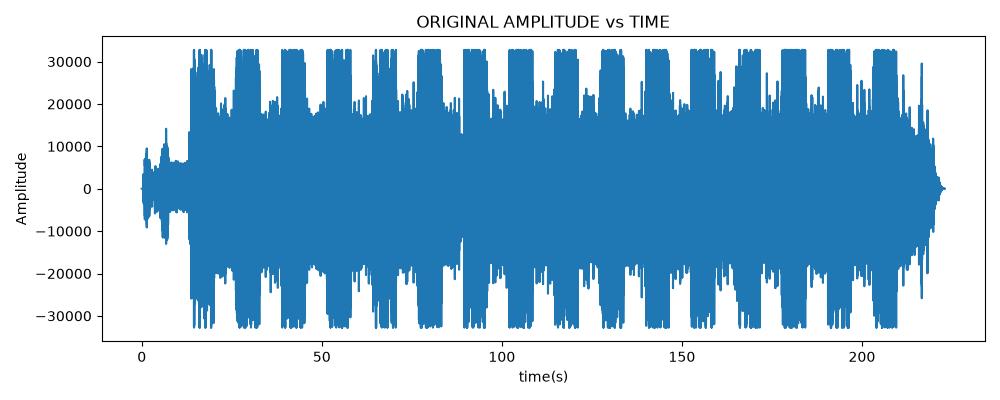

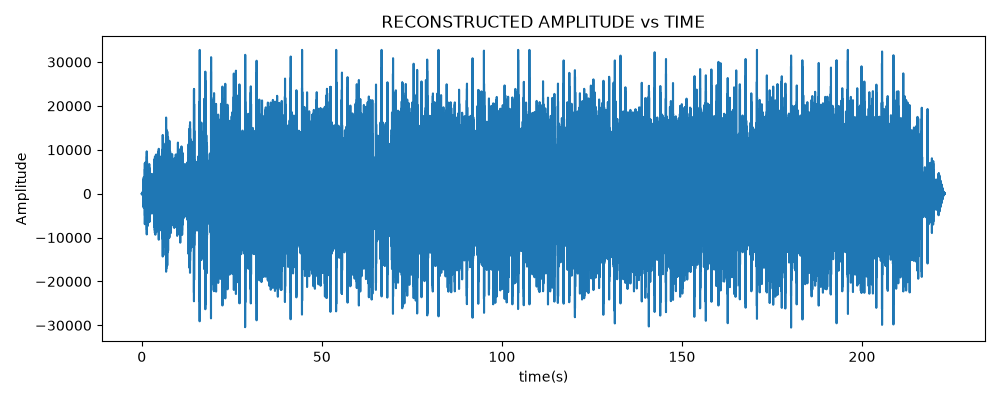

In [12]:
reconstructed_data = inverse_transform(f_transform_left_new, f_transform_right_new, sample_rate, 'a_milli_transferred.wav')
original_data = np.stack((left_data, right_data), axis=1)

delta = reconstructed_data - original_data
print(np.mean(np.abs(delta)))
reconstructed_ld = reconstructed_data[:, 0]
duration = len(original_data) / sample_rate
time = np.linspace(0.0, duration, num=len(original_data))

dbfs_ref = 32768.0
plot(time, left_data, 'ORIGINAL AMPLITUDE vs TIME', 'time(s)', 'Amplitude')
plot(time, reconstructed_ld, 'RECONSTRUCTED AMPLITUDE vs TIME', 'time(s)', 'Amplitude')